In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap.plot
from sklearn.preprocessing import LabelEncoder
import matplotlib.cm as cmap
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')
from mutiple_group_test import my_oneWayAnova
from mutiple_group_test import Shapiro_Wilk
from mutiple_group_test import Kruskal_Wallis

C:\Users\nVoke\AppData\Roaming\Python\Python38\site-packages\statsmodels\compat\pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [3]:
allen_path=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification'
outpath=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification\features(inhibitory)'
features_allen=pd.read_excel(allen_path+'\\intrinsical_electro_summary(inhibitory).xlsx')
cell_list=features_allen.cell_name.values
len(cell_list)

96

In [ ]:

manual_path=r'F:\jcy\humen_brain\electrophysiology\all_nerons'
features_manual =pd.read_excel(manual_path+'\\summary_features(inhibitory).xlsx')
overlap=[i for i in features_manual.cell_name.values if i in cell_list]

len(overlap)

75

In [4]:
valid_features_allen=features_allen[features_allen['cell_name'].isin(overlap)]
valid_features_manual=features_manual[features_manual['cell_name'].isin(overlap)]

rep_paras=[i for i in features_allen.columns if i in features_manual.columns and i!='cell_name']
valid_features_manual=valid_features_manual.drop(rep_paras,axis='columns' )
valid_features_manual

,cell_name,peak_thre,half_width,DepoR,RepoR,AHPAmp,AHP_latency,RMP,Fire_rate,IR,IS1,IS2,Tau
0,frontal_lobe_0822_cell11,-46.571832,2.903289,2.426147,-0.429254,-23.739062,17.267105,-63.7,11.14,328.22,0.052510,0.081153,20.975124
1,frontal_lobe_1123_cell15,-53.961182,0.000000,2.325439,-0.756836,4.315186,15.470000,-54.3,NaN,189.69,0.016370,NaN,6.010033
2,frontal_lobe_1123_cell26,-40.942383,1.920000,2.429199,-0.836182,4.205322,18.690000,-44.5,NaN,470.91,0.123485,0.176050,8.432653
3,frontal_lobe_1207_cell2,-28.224400,2.821429,1.961844,-0.544957,1.656669,13.278571,-54.2,NaN,174.38,0.122640,NaN,4.323037
4,frontal_lobe_1207_cell3,-38.022359,3.037500,1.785278,-0.437419,-5.467733,15.829167,-49.9,NaN,209.41,0.089262,0.111770,12.432897
5,frontal_lobe_1207_cell4,-41.695731,1.557143,3.396170,-1.033238,6.365095,15.157143,-49.3,NaN,227.13,0.077232,0.094697,8.421056
6,frontal_lobe_1207_cell7,-41.891915,1.114286,1.416888,-0.483922,-3.326416,18.828571,-58.4,NaN,104.24,NaN,NaN,10.017148
7,occipital_lobe_0904_cell2,-36.132812,1.912500,7.957458,-1.037598,-3.440857,11.012500,-55.8,NaN,205.05,0.066345,0.090770,17.701387
8,occipital_lobe_0904_cell3,-41.709900,1.287500,8.865356,-1.701355,-2.517700,9.862500,-59.4,NaN,159.96,0.052698,0.053593,23.917518
9,occipital_lobe_0904_cell4,-36.555990,3.566667,2.366130,-0.437419,-20.475260,18.530000,-61.0,1.11,293.34,0.090885,0.081030,18.448849


In [5]:
feature_23=pd.merge(valid_features_allen,valid_features_manual,on='cell_name')
feature_23.to_excel(outpath+'\\feature_23_update.xlsx',index=None)
print(feature_23.head())

                  cell_name  threshold_v  latency     peak_v   trough_v  \
0  frontal_lobe_0822_cell11   -41.912079  0.01048  26.649475 -54.687500   
1  frontal_lobe_1123_cell15   -50.689697  0.00853  -7.049561 -54.901123   
2  frontal_lobe_1123_cell26   -34.729004  0.00378  12.908936        NaN   
3   frontal_lobe_1207_cell2   -38.299561  0.08448  20.782471        NaN   
4   frontal_lobe_1207_cell3   -30.010986  0.00548  18.560791 -38.764954   

    peak_amp     width  upstroke_downstroke_ratio  adaptation     AHPamp  ...  \
0  68.561554  0.004493                   5.887151    0.035255  12.669155  ...   
1  43.640137  0.001550                   2.490909         NaN   4.211426  ...   
2  47.637939       NaN                        NaN         NaN        NaN  ...   
3  59.082031       NaN                        NaN         NaN        NaN  ...   
4  48.571777  0.005925                   3.785577    0.068175   8.033752  ...   

      DepoR     RepoR     AHPAmp  AHP_latency   RMP  Fire_rate

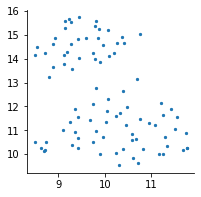

In [ ]:

summary_features=pd.read_excel(outpath+'\\inhibitory.xlsx',index_col=0)
summary_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
sum_fea_scaler=StandardScaler().fit_transform(summary_features)
sum_fea_scaler=pd.DataFrame(sum_fea_scaler,index=summary_features.index,columns=summary_features.columns)
umap_vals = umap.UMAP(n_neighbors=15,n_components=2).fit_transform(sum_fea_scaler)

plt.figure(figsize=(3,3),facecolor='white')
plt.scatter(*umap_vals.T,s=5,edgecolors=None)
sns.despine()

In [ ]:
path=r'F:\jcy\humen_brain\electrophysiology\all_nerons'
file_inhibitory=pd.read_excel(path+'\\properties_firing.xlsx',sheet_name='inhibitory')
pv_cell=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb')]  ###& (file_inhibitory['brain_region']=='occipital_lobe'
pv_cell=list(pv_cell['cell_name'])
###screening occipital, frontal, temporal PV neuron
occi_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='occipital_lobe')]
occi_pv=list(occi_pv['cell_name'])
fron_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='frontal_lobe')]
fron_pv=list(fron_pv['cell_name'])
temp_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='temporal_lobe')]
temp_pv=list(temp_pv['cell_name'])
print(np.array(occi_pv).reshape(-1,1))

[['occipital_lobe_1121_cell4']
 ['occipital_lobe_1121_cell6']
 ['occipital_lobe_1121_cell7']
 ['occipital_lobe_1121_cell14']
 ['occipital_lobe_1202_cell20']
 ['occipital_lobe_1202_cell23']
 ['occipital_lobe_1202_cell27']
 ['occipital_lobe_1206_cell7']
 ['occipital_lobe_1206_cell14']]


In [ ]:
pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in pv_cell]

occip_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in occi_pv]

fron_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in fron_pv]
temp_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in temp_pv]
print(f'location of pv neurons:{occip_pv_cluster}')

[i for i in occi_pv if i not in list(sum_fea_scaler.index)]

location of pv neurons:[34, 37, 38, 39, 44, 47, 52, 56]


['occipital_lobe_1202_cell27']

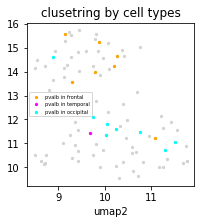

In [ ]:
plt.figure(figsize=(3,3))
plt.scatter(*umap_vals.T,s=5,c='lightgray',edgecolors=None)

plt.scatter(*umap_vals[fron_pv_cluster,:].T,s=5,c='orange',edgecolors=None,label='pvalb in frontal')
plt.scatter(*umap_vals[temp_pv_cluster,:].T,s=5,c='magenta',edgecolors=None,label='pvalb in temporal')
plt.scatter(*umap_vals[occip_pv_cluster,:].T,s=5,c='cyan',edgecolors=None,label='pvalb in occipital')

# plt.scatter(*umap_vals[pv_cluster,:].T,s=5,c='r',edgecolors=None,label='pvalb')
plt.legend(fontsize=5)

# for i in enumerate(list(sum_fea_scaler.index)):
#     plt.annotate(i[1][-11:],umap_vals[i[0],:],textcoords='offset points')

plt.title('clusetring by cell types');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(outpath+'\\clusetring by cell types0517.pdf')

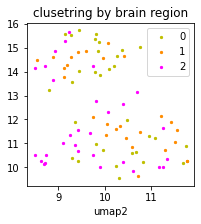

In [ ]:

sum_fea_scaler['tagets']=[i[:8] for i in sum_fea_scaler.index]
tagets=sum_fea_scaler['tagets']
encoder = LabelEncoder()
tagets = encoder.fit_transform(tagets)
encoder.classes_, np.unique(tagets, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['y','darkorange','magenta'], [0, 1, 2]):
    plt.scatter(umap_vals[tagets==i, 0], umap_vals[tagets==i, 1],s=5, c=color, label=i)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(outpath+'\\clusetring by brain region0517.pdf')

Index(['threshold_v', 'latency', 'peak_v', 'trough_v', 'peak_amp',
       'upstroke_downstroke_ratio', 'adaptation', 'isi_cv', 'avg_rate', 'tau',
       'sag', 'Rin', 'Cm', 'half_width', 'DepoR', 'RepoR', 'AHPAmp',
       'AHP_latency', 'RMP', 'IS1', 'IS2'],
      dtype='object')


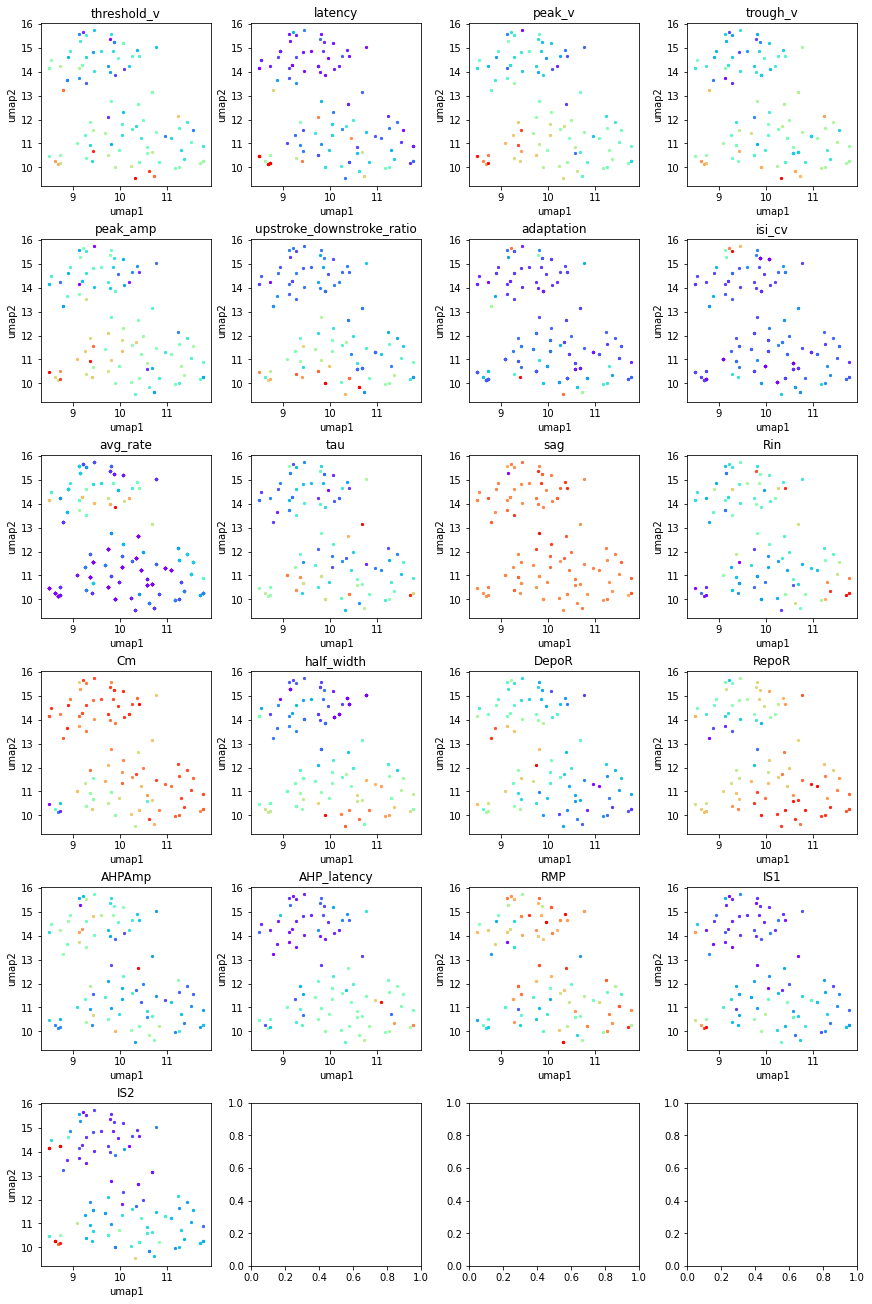

In [ ]:
parameters=sum_fea_scaler.columns[:-1]
print(parameters)
plt.subplots(nrows=6, ncols=4, figsize=(12,18),constrained_layout=True)
for i in enumerate(parameters):
    r =sum_fea_scaler[i[1]].values
    c = cmap.rainbow(numpy.int_((r-r.min())/r.ptp()*255))
    plt.subplot(6,4,i[0]+1)
    for color, cell in zip(c, r):
        plt.scatter(umap_vals[r==cell, 0], umap_vals[r==cell, 1],s=5, c=np.array(color).reshape(1,-1))
    plt.title(i[1]);plt.xlabel('umap1');plt.ylabel('umap2')
plt.savefig(outpath+'\\clusetring by parameters0517.pdf')

In [ ]:
def graph_diagram(df,para,type):
    # para=df.columns.values[:-1]
    # print(para)

    all_p=[]
    ##one-way-anova
    for i,parameters in enumerate(para):
        print(f'Paremeter{parameters}：')
        diff1,diff2=my_oneWayAnova(df,cata_name='brain_region',num_name=parameters)
        round_p=np.array([[parameters]*3,diff2['group1'],diff2['group2'],diff2['p-adj']]).T  ##['group1'],diff2['group2'],diff2['p-adj']]
        all_p.append(round_p)

    p_cross=np.array(all_p).reshape(-1,4)[:,:].tolist()

    for i in p_cross:

        if float(i[3])<0.05:
            i.append('Y')
        else:
            i.append('N')

    pd.DataFrame(p_cross,columns=['group','region1','region2','p','sig']).to_csv(root_dir+'\\'+f'{type}_sig.csv')

参数threshold_v统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal
参数latency统计学差异：
NO significant difference between the groups
occipita <= frontal_ <= temporal
参数peak_v统计学差异：
Significant difference between the groups
occipita <= frontal_ < temporal
参数trough_v统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal
参数peak_amp统计学差异：
NO significant difference between the groups
occipita <= frontal_ <= temporal
参数upstroke_downstroke_ratio统计学差异：
NO significant difference between the groups
occipita <= frontal_ <= temporal
参数adaptation统计学差异：
NO significant difference between the groups
frontal_ <= temporal <= occipita
参数isi_cv统计学差异：
NO significant difference between the groups
frontal_ <= temporal <= occipita
参数avg_rate统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal
参数tau统计学差异：
Significant difference between the groups
occipita < frontal_ <= temporal
参数sag统计学差异：
NO significant difference between 

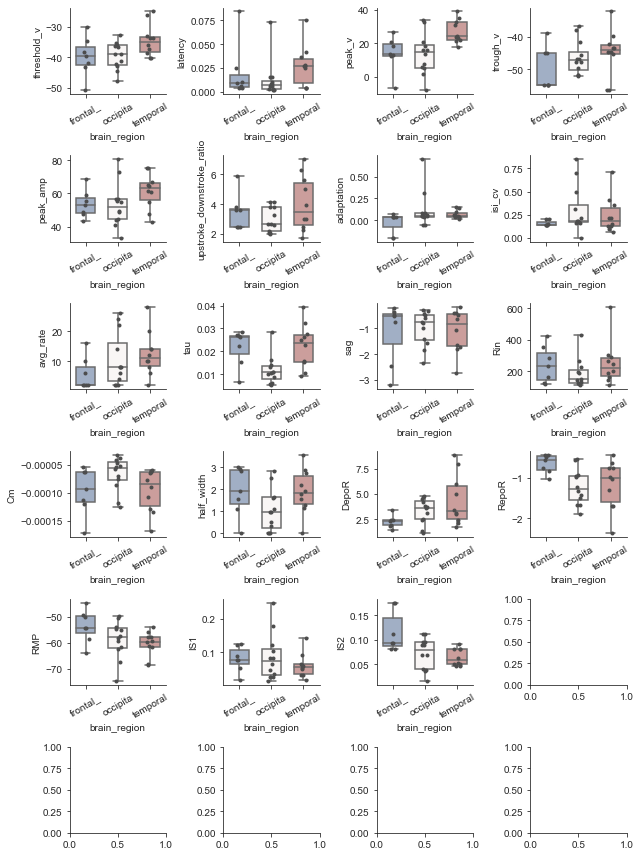

In [ ]:
root_dir=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification\features(excitory)'
features_firing =pd.read_excel(root_dir+'\\feature_23_update.xlsx',index_col=0)
# print(features_firing.head())
para=features_firing.columns
features_firing.fillna(method = 'pad', axis =0, inplace=True, limit=None)
features_firing['brain_region']=[i[:8] for  i in features_firing.index.values]
f, ax = plt.subplots(nrows=6, ncols=4,figsize=(9, 12))
sns.set_style(style="ticks")

graph_diagram(features_firing,para,'inhibitory')

for i,parameters in enumerate(para):
    print(f'Paremeter{parameters}：')

    diff1,diff2=my_oneWayAnova(features_firing,cata_name='brain_region',num_name=parameters)

    plt.subplot(6,4,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="brain_region", y=parameters, data=features_firing,whis=[0, 100], width=.6, palette="vlag")
    # plt.legend(diff2['p-adj'],loc=1)
    # Add in points to show each observation
    sns.stripplot(x="brain_region", y=parameters, data=features_firing,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)

f.tight_layout()
plt.savefig(root_dir+'\\properties_firing_excitory0309.pdf')


参数threshold_v统计学差异：
threshold_v follows a normal distribution
NO significant difference between the groups
frontal_ <= occipita <= temporal

参数latency统计学差异：
latency does not follow a normal distribution
The main effect was not significant
parameters----Significant difference between the groups,p=0.12495072787506128

参数peak_v统计学差异：
peak_v follows a normal distribution
Significant difference between the groups
occipita <= frontal_ < temporal

参数trough_v统计学差异：
trough_v does not follow a normal distribution
The main effect was not significant
parameters----Significant difference between the groups,p=0.29769543128932174

参数peak_amp统计学差异：
peak_amp follows a normal distribution
NO significant difference between the groups
occipita <= frontal_ <= temporal

参数upstroke_downstroke_ratio统计学差异：
upstroke_downstroke_ratio does not follow a normal distribution
The main effect was not significant
parameters----Significant difference between the groups,p=0.43089143155311227

参数adaptation统计学差异：
adaptati

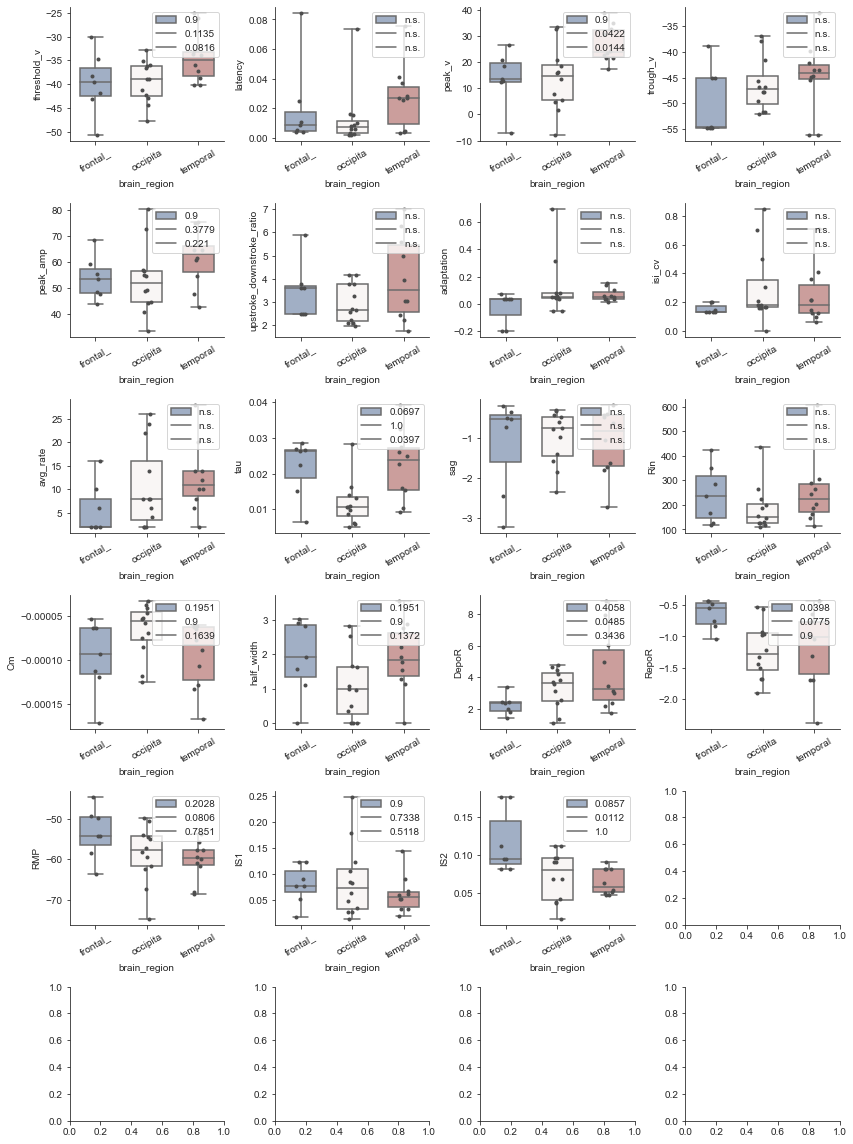

In [ ]:
root_dir=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification\features(excitory)'
features_firing =pd.read_excel(root_dir+'\\feature_23_update.xlsx',index_col=0)
# print(features_firing.head())
para=features_firing.columns
features_firing.fillna(method = 'pad', axis =0, inplace=True, limit=None)
features_firing['brain_region']=[i[:8] for  i in features_firing.index.values]
f, ax = plt.subplots(nrows=6, ncols=4,figsize=(12, 16))
sns.set_style(style="ticks")
for i,parameters in enumerate(para):
    print(f'\nParemeter{parameters}：')

    s_w=Shapiro_Wilk(features_firing,cata_name='brain_region',num_name=parameters)
    p=['n.s.','n.s.','n.s.']
    ###one-way anova
    if s_w:
        diff1,diff2=my_oneWayAnova(features_firing,cata_name='brain_region',num_name=parameters)
        p=diff2['p-adj']
    ###KW+dunn
    else:
        p_kw,p_dunn=Kruskal_Wallis(features_firing,cata_name='brain_region',num_name=parameters)
        print(f'parameters----Significant difference between the groups,p={p_kw}')
        p=p_dunn

    plt.subplot(6,4,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="brain_region", y=parameters, data=features_firing,whis=[0, 100], width=.6, palette="vlag")
    plt.legend((p),loc=1)
    # Add in points to show each observation
    sns.stripplot(x="brain_region", y=parameters, data=features_firing,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)
f.tight_layout()
plt.savefig(root_dir+'\\properties_firing_excitory.pdf')